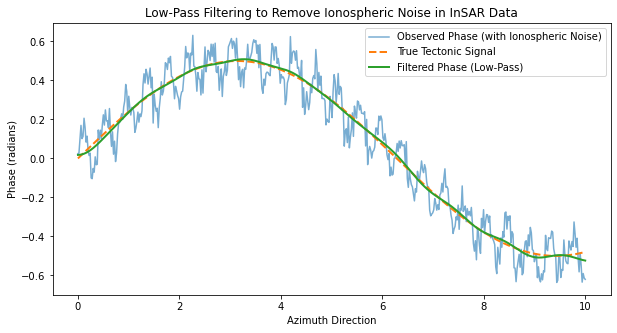

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Generate synthetic data
np.random.seed(42)
azimuth_samples = 500  # Number of points along azimuth
x = np.linspace(0, 10, azimuth_samples)  # Azimuth axis

# Simulate low-frequency tectonic deformation signal (smooth trend)
tectonic_signal = 0.5 * np.sin(0.5 * x)  # Long-wavelength deformation

# Simulate high-frequency ionospheric noise
ionospheric_noise = 0.1 * np.sin(15 * x) + 0.05 * np.random.randn(azimuth_samples)

# Combine to form observed InSAR phase
observed_phase = tectonic_signal + ionospheric_noise

# Design a low-pass filter (Butterworth)
def lowpass_filter(data, cutoff_freq, fs, order=4):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Apply low-pass filter
fs = 100  # Sampling frequency (arbitrary)
cutoff_freq = 2  # Cutoff frequency (to remove high-freq ionospheric noise)
filtered_phase = lowpass_filter(observed_phase, cutoff_freq, fs)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(x, observed_phase, label="Observed Phase (with Ionospheric Noise)", alpha=0.6)
plt.plot(x, tectonic_signal, label="True Tectonic Signal", linestyle="--", linewidth=2)
plt.plot(x, filtered_phase, label="Filtered Phase (Low-Pass)", linewidth=2)
plt.xlabel("Azimuth Direction")
plt.ylabel("Phase (radians)")
plt.legend()
plt.title("Low-Pass Filtering to Remove Ionospheric Noise in InSAR Data")
plt.show()


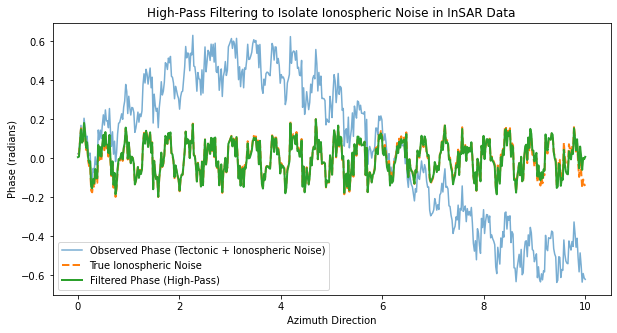

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Generate synthetic data
np.random.seed(42)
azimuth_samples = 500  # Number of points along azimuth
x = np.linspace(0, 10, azimuth_samples)  # Azimuth axis

# Simulate low-frequency tectonic deformation signal (long-wavelength)
tectonic_signal = 0.5 * np.sin(0.5 * x)  # Smooth tectonic trend

# Simulate high-frequency ionospheric noise (short-wavelength)
ionospheric_noise = 0.1 * np.sin(15 * x) + 0.05 * np.random.randn(azimuth_samples)

# Combine to form observed InSAR phase
observed_phase = tectonic_signal + ionospheric_noise

# Design a high-pass filter (Butterworth)
def highpass_filter(data, cutoff_freq, fs, order=4):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

# Apply high-pass filter
fs = 100  # Sampling frequency (arbitrary)
cutoff_freq = 2  # Cutoff frequency (removes long-wavelength tectonic signal)
filtered_phase = highpass_filter(observed_phase, cutoff_freq, fs)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(x, observed_phase, label="Observed Phase (Tectonic + Ionospheric Noise)", alpha=0.6)
plt.plot(x, ionospheric_noise, label="True Ionospheric Noise", linestyle="--", linewidth=2)
plt.plot(x, filtered_phase, label="Filtered Phase (High-Pass)", linewidth=2)
plt.xlabel("Azimuth Direction")
plt.ylabel("Phase (radians)")
plt.legend()
plt.title("High-Pass Filtering to Isolate Ionospheric Noise in InSAR Data")
plt.show()


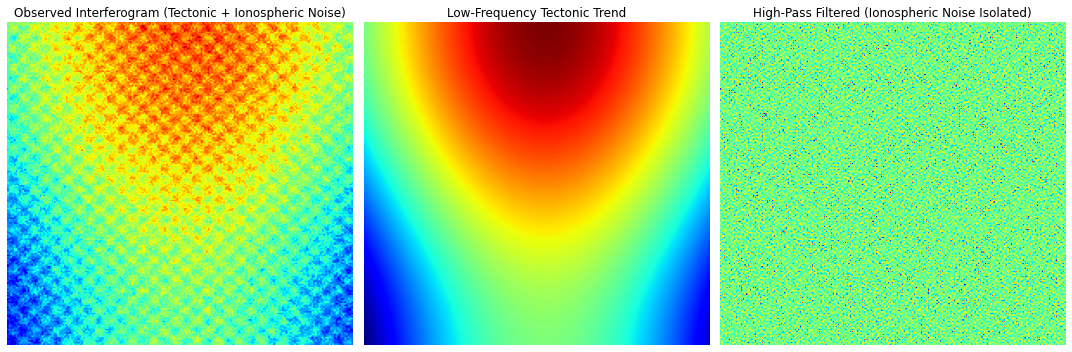

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# Generate a synthetic interferogram
np.random.seed(42)
size = (200, 200)  # Interferogram size (azimuth x range)
x = np.linspace(0, 10, size[1])
y = np.linspace(0, 10, size[0])
X, Y = np.meshgrid(x, y)

# Simulate long-wavelength tectonic deformation (low-frequency component)
tectonic_trend = 2 * np.sin(0.3 * X) + 1 * np.cos(0.3 * Y)

# Simulate short-wavelength ionospheric noise (high-frequency component)
ionospheric_noise = 0.5 * np.sin(10 * X) * np.sin(10 * Y) + 0.3 * np.random.randn(*size)

# Combine both to simulate the observed interferogram
observed_interferogram = tectonic_trend + ionospheric_noise

# Apply a high-pass spatial filter (Laplacian kernel)
laplacian_filter = np.array([[0, -1, 0],
                             [-1, 4, -1],
                             [0, -1, 0]])

filtered_interferogram = ndimage.convolve(observed_interferogram, laplacian_filter, mode='reflect')

# Plot the results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(observed_interferogram, cmap='jet', aspect='auto')
axs[0].set_title("Observed Interferogram (Tectonic + Ionospheric Noise)")
axs[0].axis("off")

axs[1].imshow(tectonic_trend, cmap='jet', aspect='auto')
axs[1].set_title("Low-Frequency Tectonic Trend")
axs[1].axis("off")

axs[2].imshow(filtered_interferogram, cmap='jet', aspect='auto')
axs[2].set_title("High-Pass Filtered (Ionospheric Noise Isolated)")
axs[2].axis("off")

plt.tight_layout()
plt.show()


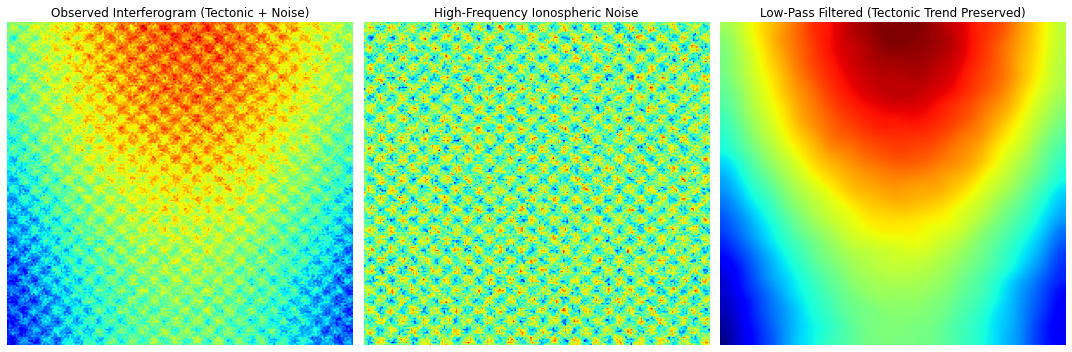

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# Generate a synthetic interferogram
np.random.seed(42)
size = (200, 200)  # Interferogram size (azimuth x range)
x = np.linspace(0, 10, size[1])
y = np.linspace(0, 10, size[0])
X, Y = np.meshgrid(x, y)

# Simulate long-wavelength tectonic deformation (low-frequency component)
tectonic_trend = 2 * np.sin(0.3 * X) + 1 * np.cos(0.3 * Y)

# Simulate short-wavelength ionospheric noise (high-frequency component)
ionospheric_noise = 0.5 * np.sin(10 * X) * np.sin(10 * Y) + 0.3 * np.random.randn(*size)

# Combine both to simulate the observed interferogram
observed_interferogram = tectonic_trend + ionospheric_noise

# Apply a spatial low-pass filter (Gaussian filter with sigma=5)
low_pass_filtered = ndimage.gaussian_filter(observed_interferogram, sigma=5)

# Plot the results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(observed_interferogram, cmap='jet', aspect='auto')
axs[0].set_title("Observed Interferogram (Tectonic + Noise)")
axs[0].axis("off")

axs[1].imshow(ionospheric_noise, cmap='jet', aspect='auto')
axs[1].set_title("High-Frequency Ionospheric Noise")
axs[1].axis("off")

axs[2].imshow(low_pass_filtered, cmap='jet', aspect='auto')
axs[2].set_title("Low-Pass Filtered (Tectonic Trend Preserved)")
axs[2].axis("off")

plt.tight_layout()
plt.show()


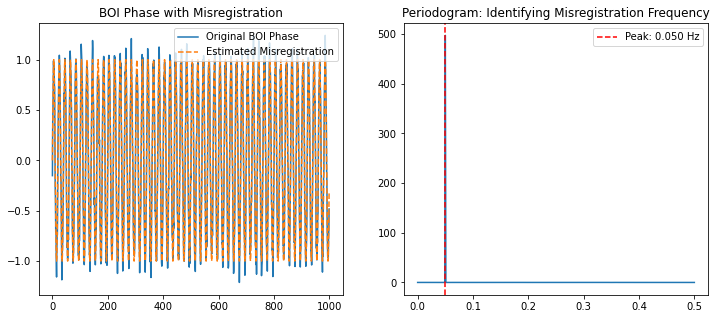

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# Simulate BOI phase with misregistration error + noise
N = 1000  # Number of burst overlaps
fs = 1.0  # Sampling frequency in Hz (arbitrary for simulation)
f_mis = 0.05  # Misregistration frequency component (arbitrary)
t = np.arange(N) / fs

# Generate simulated BOI phase
phi_mis = np.sin(2 * np.pi * f_mis * t)  # Misregistration signal
phi_noise = np.random.normal(0, 0.1, N)  # Gaussian noise
phi_BOI = phi_mis + phi_noise  # Simulated BOI phase

# Compute the periodogram
frequencies, power = periodogram(phi_BOI, fs)

# Identify the peak frequency (dominant misregistration component)
peak_freq = frequencies[np.argmax(power)]

# Estimate misregistration phase
estimated_mis = np.sin(2 * np.pi * peak_freq * t)

# Corrected BOI phase
phi_BOI_corrected = phi_BOI - estimated_mis

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, phi_BOI, label='Original BOI Phase')
plt.plot(t, estimated_mis, label='Estimated Misregistration', linestyle='dashed')
plt.legend()
plt.title("BOI Phase with Misregistration")

plt.subplot(1, 2, 2)
plt.plot(frequencies, power)
plt.axvline(x=peak_freq, color='r', linestyle='dashed', label=f'Peak: {peak_freq:.3f} Hz')
plt.legend()
plt.title("Periodogram: Identifying Misregistration Frequency")

plt.show()


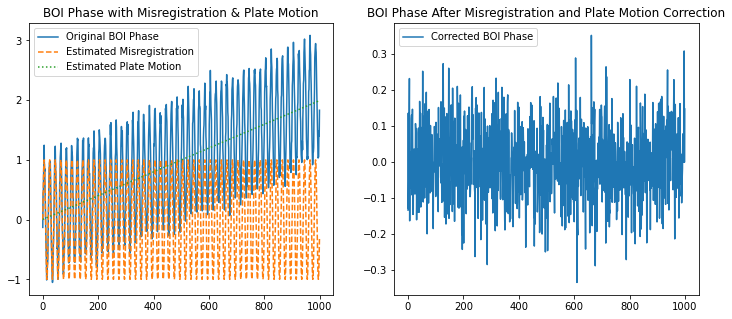

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.optimize import curve_fit

# Simulated parameters
N = 1000  # Number of burst overlaps
fs = 1.0  # Sampling frequency
f_mis = 0.05  # Misregistration frequency component
plate_velocity = 0.002  # Simulated plate motion (linear trend)

t = np.arange(N) / fs

# Simulate BOI misregistration phase (misregistration + plate motion)
phi_mis = np.sin(2 * np.pi * f_mis * t)  # Periodic misregistration error
phi_plate = plate_velocity * t  # Linear trend due to plate motion
phi_noise = np.random.normal(0, 0.1, N)  # Noise

phi_BOI = phi_mis + phi_plate + phi_noise  # Simulated BOI phase

# Compute the periodogram to estimate misregistration frequency
frequencies, power = periodogram(phi_BOI, fs)
peak_freq = frequencies[np.argmax(power)]

# Estimated misregistration phase
estimated_mis = np.sin(2 * np.pi * peak_freq * t)

# Fit a linear model to estimate plate motion
def linear_model(x, a, b):
    return a * x + b

params, _ = curve_fit(linear_model, t, phi_BOI - estimated_mis)
estimated_plate_motion = linear_model(t, *params)

# Corrected BOI phase (removing both misregistration and plate motion)
phi_BOI_corrected = phi_BOI - estimated_mis - estimated_plate_motion

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, phi_BOI, label='Original BOI Phase')
plt.plot(t, estimated_mis, label='Estimated Misregistration', linestyle='dashed')
plt.plot(t, estimated_plate_motion, label='Estimated Plate Motion', linestyle='dotted')
plt.legend()
plt.title("BOI Phase with Misregistration & Plate Motion")

plt.subplot(1, 2, 2)
plt.plot(t, phi_BOI_corrected, label='Corrected BOI Phase')
plt.legend()
plt.title("BOI Phase After Misregistration and Plate Motion Correction")

plt.show()


In [1]:
##Li et al. Dead Sea Fault

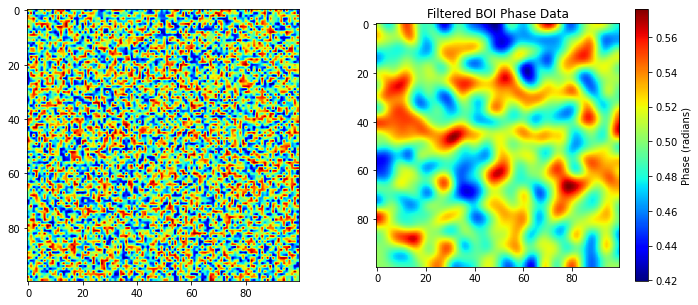

In [5]:
import numpy as np
from scipy.ndimage import gaussian_filter

# Load BOI phase data (2D array)
boi_phase = np.random.rand(100, 100)  # Example data

# Apply Gaussian filter with a 3-pixel standard deviation
filtered_phase = gaussian_filter(boi_phase, sigma=3)

# Display filtered phase (use matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(boi_phase, cmap='jet')
plt.subplot(1, 2, 2)
plt.imshow(filtered_phase, cmap='jet')
plt.colorbar(label="Phase (radians)")
plt.title("Filtered BOI Phase Data")
plt.show()


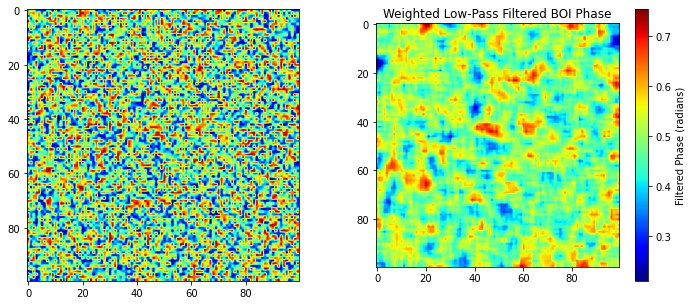

In [7]:
def weighted_low_pass_filter(phase, coherence, window_size=5):
    """Applies a weighted low-pass filter using coherence as weights."""
    from scipy.ndimage import uniform_filter
    
    # Compute weighted phase and normalize
    weighted_phase = uniform_filter(phase * coherence, size=window_size)
    weight_sum = uniform_filter(coherence, size=window_size)
    
    # Avoid division by zero
    weight_sum[weight_sum == 0] = 1e-6
    
    return weighted_phase / weight_sum

# Example phase and coherence matrices
phase_data = np.random.rand(100, 100)  # Simulated BOI phase
coherence_data = np.random.rand(100, 100)  # Simulated coherence

# Apply weighted low-pass filter
filtered_phase = weighted_low_pass_filter(phase_data, coherence_data)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(phase_data, cmap='jet')
plt.subplot(1, 2, 2)
plt.imshow(filtered_phase, cmap='jet')
plt.colorbar(label="Filtered Phase (radians)")
plt.title("Weighted Low-Pass Filtered BOI Phase")
plt.show()
